# Multiarm Bandit

# Basic Imports

In [30]:
from typing import Iterable
import random

import numpy as np
import matplotlib.pyplot as plt

from tqdm import trange


## The Environment — Process Model

### Simulating one Bandit

In [31]:
class Bandit:
    """A bandit with uniform reward distribution."""

    def __init__(self, mean: float, span: float):
        """Initialize the bandit.

        Regardless of the received action, the bandit will return reward
        uniformly sampled from segment [`mean`-`span`, `mean`+`span`].

        Args:
            mean (float): Mean (expected) value of the reward.
            span (float): Span of the reward.
        """
        self.mean = mean
        self.span = span

    def pull_leaver(self) -> float:
        """Pull leaver and obtain reward.

        Returns:
            float: The obtained reward.
        """
        return self.mean + 2*self.span * (random.random()-0.5) # random number in [mean-span, mean+span]

### Testing one Bandit

We should always test a piece of code :) This is not a formal test, but it is still a test.

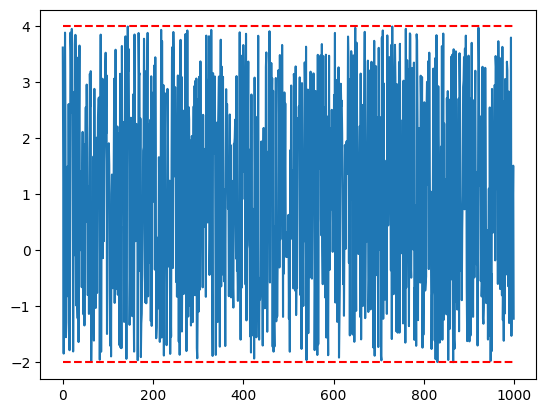

In [32]:
test_mean = 1.0
test_span = 3.0
test_len = 1000

test_bandit = Bandit(test_mean, test_span)
test_rewards = [test_bandit.pull_leaver() for _ in range(test_len)]

plt.plot(test_rewards, label="rewards")
plt.plot((test_mean+test_span)*np.ones(test_len), linestyle="--", color="r")
plt.plot((test_mean-test_span)*np.ones(test_len), linestyle="--", color="r")

### Building an Environment of Bandits

Now, we define an environment consisting of several bandits.

In [ ]:
class BanditsEnvironment:
    """An environment consisting of multiple bandits."""

    def __init__(self, bandits: Iterable[Bandit], penalty=1000):
        """Initialize the environment.

        Args:
            bandits (iter[Bandit]): Bandits to be used within the environment.
            penalty (int, optional):
                If the external agents attempts to use a bandit not in the list,
                i.e. if the chosen action is negative or bigger than the index of
                the last bandit, the returned reward will be `-penalty`. Defaults to 1000.
        """
        self.bandits: list[Bandit] = list(bandits)
        self.penalty = penalty

    def take_action(self, a: int): # action is actually the bandit's index
        """
        Select bandit `a` and pull its leaver.

        If the selected agent is valid, return the obtained reward.
        Otherwise, return negative penalty.
        """
        if a<0 or a>=len(self.bandits):
            return -self.penalty # penalty, as opposed to the reward being self.penalty
        else:
            return self.bandits[a].pull_leaver()

<div class="alert alert-block alert-info">
<b>Tip:</b>
The `Sequence` and `Iterable` **abstract base classes** (can also be used as **type annotations**) usually adhere to the following conventions:

* `Iterable` is any object that defines `__iter__` or `__getitem__`.
* `Sequence` is any object that defines `__getitem__` and `__len__`. By definition, any sequence is an iterable.

The `Sequence` class also defines other methods such as `__contains__`, `__reversed__` that calls the two required methods.

`list`, `tuple`, `str` are the most common sequences. Some built-in iterables are not sequences.
</div>

For more tips and tricks regarding notebook markdown, please see [here](https://towardsdatascience.com/modernize-your-sinful-python-code-with-beautiful-type-hints-4e72e98f6bf1).


### Testing the Environment

Let us now test the environment. We will build it so that the mean value of the reward returned by each bandit is equal to the square of its index. The span will be equal to the index.

In [34]:
test_env_size = 5
test_bandits = [Bandit(i**2, i) for i in range(test_env_size)]
test_env = BanditsEnvironment(test_bandits)

We will first test whether one of the bandits behaves as expected...

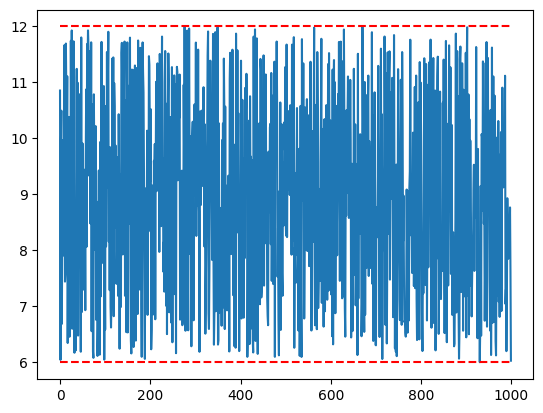

In [35]:
selected_bandit = 3
test_len = 1000
test_rewards = [test_env.take_action(selected_bandit) for _ in range(test_len)]

plt.plot(test_rewards, label="rewards")
plt.plot((selected_bandit**2+selected_bandit)*np.ones(test_len), linestyle="--", color="r")
plt.plot((selected_bandit**2-selected_bandit)*np.ones(test_len), linestyle="--", color="r")

Then, we will test if the environment behaves correctly when an invalid action is given...

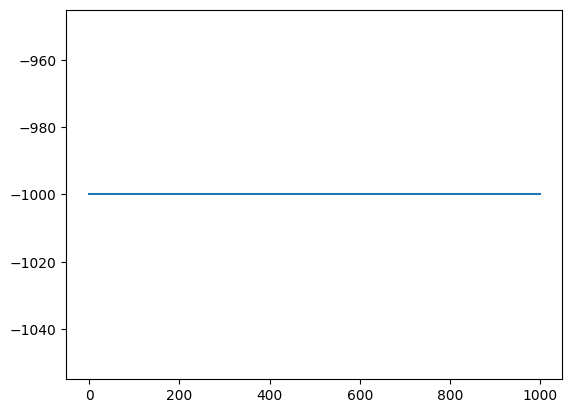

In [36]:
selected_bandit = -1
test_rewards = [test_env.take_action(selected_bandit) for _ in range(test_len)]

plt.plot(test_rewards, label="rewards")

Finally, let us check if the code runs with arbitrarily selected actions. This is quite tricky to do, since the whole system behaves stochastically. However, we know that the bandits are independent, and also that their mean values are 0, 1, 4, 9, and 16. Assuming each bandit is activated with the same probability, the mean value rewards obtained after many actions should be (0 + 1 + 4 + 9 + 16)/5 = 6.

In [ ]:
#check to see what our total gain will be
test_rewards = [test_env.take_action(random.randint(0, 4)) for _ in range(test_len)]
test_mean = sum(test_rewards)/test_len

print("TEST MEAN = ", test_mean)

## Decision Policies

In [ ]:
# before the test we have information about which bandit gives the greatest benefit and we always choose only that bandit regardless of the other values
# we learn nothing about the environment, it just forces the best bandit
# we maximize the gain, but it is not necessarily accurate because we learn nothing about the environment
def choose_greedy_action(q):
    return np.argmax(q)

In [ ]:
# the gains of the bandits, of which we have five
test_q = [1, 2, 3, 2, 1]

test_actions = [choose_greedy_action(test_q) for _ in range(test_len)] # always picks the bandit with index two

plt.plot(test_actions)

In [ ]:
# bandits are chosen completely at random, which is why there is no need to pass the bandits' gains, only the number of bandits
# exploratory policy, we learn about the environment
def choose_random_action(n):
    return random.randint(0, n-1)

In [ ]:
# with Eps close to zero we choose randomly with low probability, and with high probability we choose greedily
# the value of epsilon depends on the nature of the problem, but for now it is a constant for us
def choose_eps_greedy_action(q, eps):
    if random.random() > eps: # random gives us a value between 0 and 1, every number in that range has an equal probability of being chosen - UNIFORM DISTRIBUTION, random is our probability generator
    # is our probability greater than epsilon? -> YES: we choose greedily, less than or equal to epsilon we choose randomly
        return choose_greedy_action(q)
    else:
        return choose_random_action(len(q))

In [ ]:
plt.subplot(3, 1, 1)
plt.plot([choose_eps_greedy_action(test_q, 1.0) for _ in range(test_len)]) # epsilon = 1 WHICH MEANS we choose randomly absolutely (100%) and zero percent greedily
plt.subplot(3, 1, 2)
plt.plot([choose_eps_greedy_action(test_q, 0.2) for _ in range(test_len)]) # epsilon 0.2 which means we choose randomly 20% of the time and greedily 80% of the time
plt.subplot(3, 1, 3)
plt.plot([choose_eps_greedy_action(test_q, 0.01) for _ in range(test_len)]) # epsilon 0.01, we choose randomly 1% of the time and greedily the remaining 99% of the time; we think that in this case we get the highest gain, although we don't even know the values for the other bandits since we get no information about the environment

## Training Loop

In [ ]:
# Updating the gain, iterative method
# if alpha is zero we trust ourselves more, the larger alpha is the more we trust the environment
# r = reward
BANDITS_NO = 5
ATTEMPTS_NO = 5000
ALPHA = 0.1 # we trust ourselves more than the environment
EPSILON = 0.1 # ABOUT 10% WILL BE RANDOM, the remaining 90% greedy

bandits = [Bandit(10*(random.random()-0.5), 5*random.random()) for _ in range(BANDITS_NO)] # it doesn't matter how we create the bandits, the important thing is to pass the mean value
env = BanditsEnvironment(bandits)

q = [100 for _ in range(BANDITS_NO)] # defining the list of gains, START OF THE ALGORITHM, so that all bandits initially have the same high gain so that the probability of being chosen is the same, we won't favor any bandit
rewards = []
for t in trange(ATTEMPTS_NO):
    a = choose_eps_greedy_action(q, EPSILON)
    r = env.take_action(a) # based on the action we update the gain value
    q[a] = q[a] + ALPHA * (r - q[a]) # END OF THE ALGORITHM = vector q, IN THE NEXT TASK THIS IS THE START
    # just for logging
    rewards.append(r)

In [ ]:
# how well our estimated mean value (q) of the bandits matches the obtained one (x)
plt.scatter(range(len(q)), q, marker=".")
plt.scatter(range(len(q)), [b.mean for b in env.bandits], marker="x")

In [ ]:
# orange is the ideal reward case, and blue is how our rewards get updated
g = np.cumsum(rewards)
max_r = max([b.mean for b in env.bandits])
plt.plot(g)
plt.plot(np.cumsum(max_r * np.ones(len(g))))

Assignments for Individual Work
1. Experiment with the value of epsilon. Try smaller
values, and verify that the slope difference is smaller. Verify also the oposite fact: increasing epsilon decreases the slope of the plotted achieved gain. Explain.

2. Perform a training run to learn the q vector (in essence, to estimate the mean value of the reward returned by each bandit). Create a test loop, in which the learned q values remain fixed. Compare performance of the agent to the ideal performance (as it is done in the previous point).

3. Plot the change of the estimated q values in time. Show that with passing time the algorithm sucessfully approximates mean rewards of all bandits.

4. Modify the environment so that the mean values of all bandits change in time. Repeat the training procedure. Evaluate its effectiveness.

1. Experiment with the value of epsilon. Try smaller values, and verify that the slope difference is smaller. Verify also the oposite fact: increasing epsilon decreases the slope of the plotted achieved gain. Explain.

In [ ]:
def run_experiment(epsilon: float, alpha: float = 0.1, bandits_no: int = 5, attempts_no: int = 5000):


    bandits = [Bandit(10*(random.random()-0.5), 5*random.random()) for _ in range(bandits_no)]
    env = BanditsEnvironment(bandits)

    q = [100 for _ in range(bandits_no)]
    rewards = []

    for t in range(attempts_no):
        a = choose_eps_greedy_action(q, epsilon)
        r = env.take_action(a)
        q[a] = q[a] + alpha * (r - q[a])
        rewards.append(r)

    g = np.cumsum(rewards)  # achieved cumulative gain
    max_r = max([b.mean for b in env.bandits])
    optimal = np.cumsum([max_r] * attempts_no)  # maximum possible cumulative gain

    return g, optimal


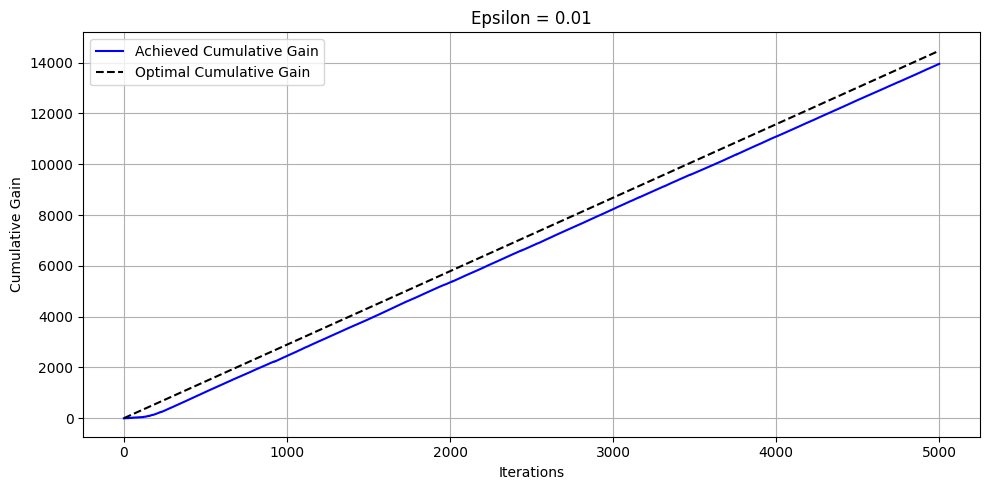

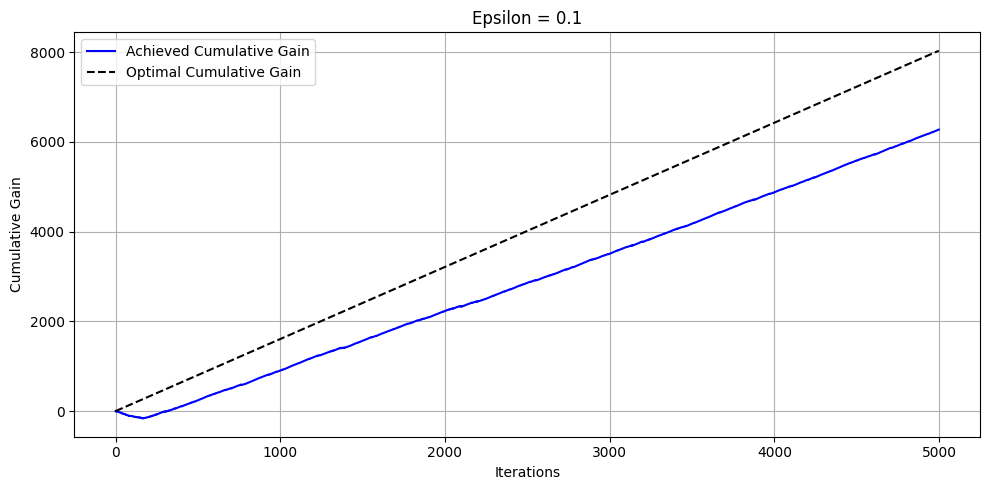

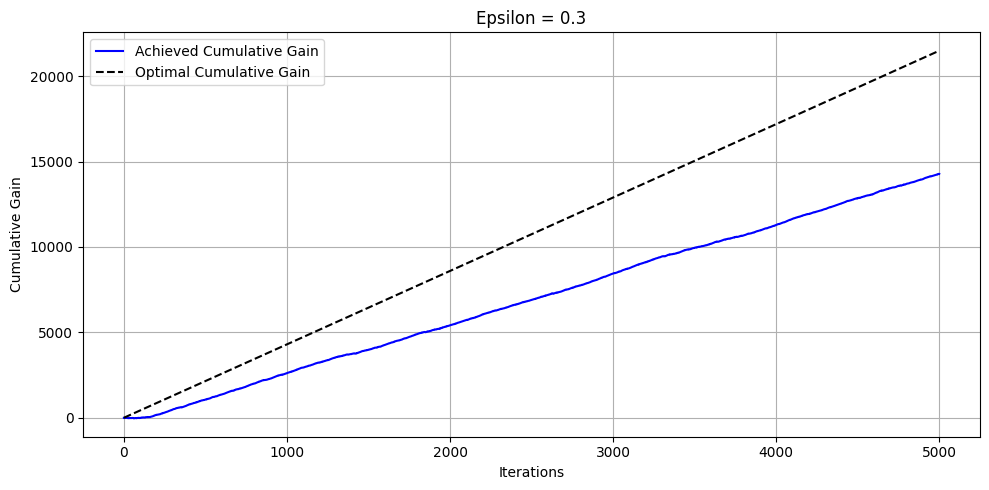

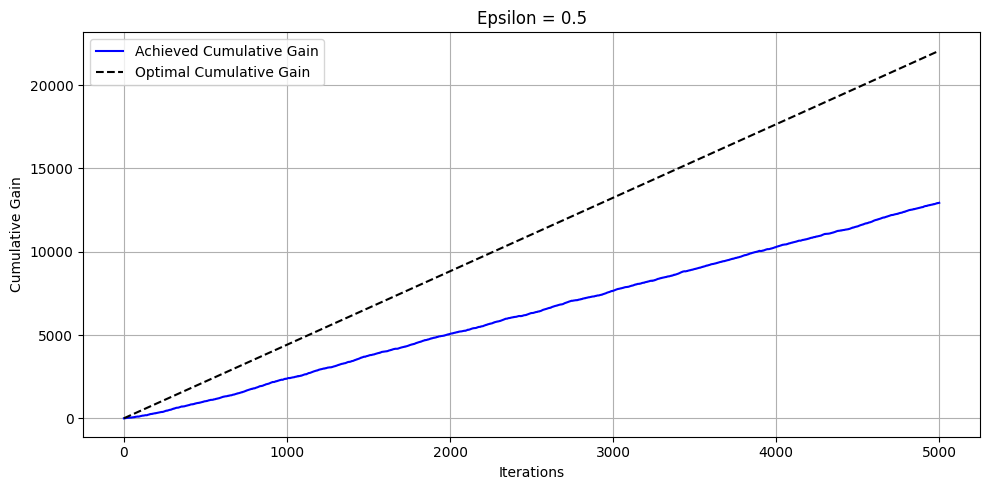

In [47]:
epsilons = [0.01, 0.1, 0.3, 0.5]

for eps in epsilons:
    g, optimal = run_experiment(eps)

    plt.figure(figsize=(10, 5))
    plt.plot(g, label="Achieved Cumulative Gain", color="blue")
    plt.plot(optimal, label="Optimal Cumulative Gain", linestyle="--", color="black")

    plt.title(f"Epsilon = {eps}")
    plt.xlabel("Iterations")
    plt.ylabel("Cumulative Gain")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


**Explanation:**

The epsilon parameter controls the balance between exploration of the environment for the purpose of learning and gathering information, and exploitation aimed at maximizing the gain.

- With a smaller epsilon (e.g. the plot where epsilon = 0.001), the agent almost always chooses the greedy policy, i.e. the action that yields the highest estimated q-value. After the initial learning phase, the agent continues to exploit the best machine (in the case of this task), which is why the cumulative gain rises sharply and stays close to the optimal gain.

- With a larger epsilon (e.g. the plot where epsilon = 0.5), the agent chooses a random machine in 50% of cases, even when it knows that machine yields a lower estimated q-value, for the sake of exploring the environment. However, this way a lot of steps are spent on bad machines, so the average reward per step is lower -> and consequently the slope of the cumulative gain curve is gentler and further from the optimal one

Larger epsilon -> More exploration of the environment -> Lower average reward -> Smaller slope of the cumulative gain (further from optimal)


2. Perform a training run to learn the q vector (in essence, to estimate the mean value of the reward returned by each bandit). Create a test loop, in which the learned q values remain fixed. Compare performance of the agent to the ideal performance (as it is done in the previous point).

  - Try taking the learned q, and try 100 iterations with epsilon = 0

In [ ]:
def train_q_vector(epsilon=0.1, alpha=0.1, bandits_no=5, attempts_no=5000):
    bandits = [Bandit(10*(random.random()-0.5), 5*random.random()) for _ in range(bandits_no)]
    env = BanditsEnvironment(bandits)

    q = [100 for _ in range(bandits_no)]
    rewards = []

    for t in range(attempts_no):
        a = choose_eps_greedy_action(q, epsilon)
        r = env.take_action(a)
        q[a] = q[a] + alpha * (r - q[a])  # this is the starting point of task 2
        rewards.append(r)

    return q, env


In [ ]:
def test_with_fixed_q(q_fixed, env, attempts_no=5000):
    rewards = []
    for _ in range(attempts_no):
        a = choose_greedy_action(q_fixed)  # in the test phase we only use greedy (no exploration of the environment)
        r = env.take_action(a)
        rewards.append(r)

    g = np.cumsum(rewards)
    max_r = max([b.mean for b in env.bandits])
    optimal = np.cumsum([max_r] * attempts_no)
    return g, optimal


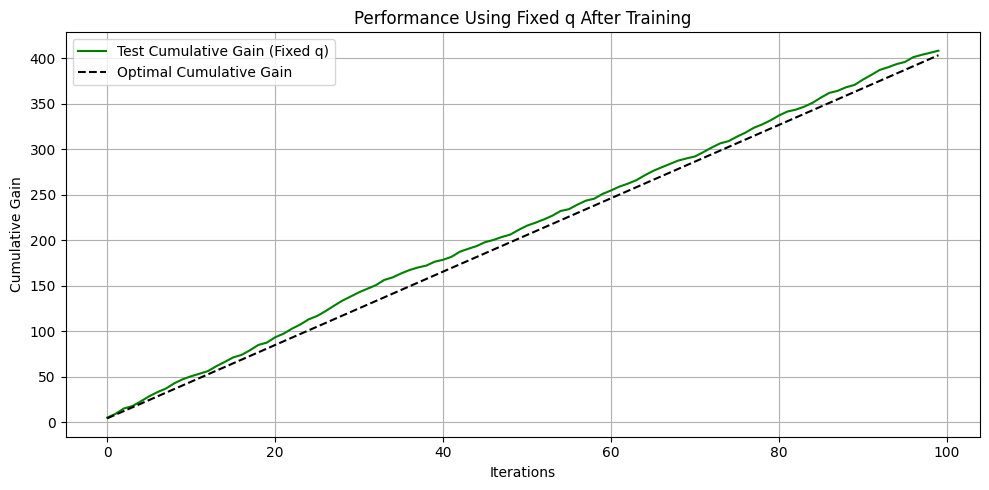

In [50]:

q_learned, env = train_q_vector(epsilon=0.1, alpha=0.1, attempts_no=5000)

g, optimal = test_with_fixed_q(q_learned, env, attempts_no=100)

plt.figure(figsize=(10, 5))
plt.plot(g, label="Test Cumulative Gain (Fixed q)", color="green")
plt.plot(optimal, label="Optimal Cumulative Gain", linestyle="--", color="black")
plt.title("Performance Using Fixed q After Training")
plt.xlabel("Iterations")
plt.ylabel("Cumulative Gain")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


3. Plot the change of the estimated q values in time. Show that with passing time the algorithm sucessfully approximates mean rewards of all bandits.

In [ ]:
def track_q_evolution(epsilon=0.1, alpha=0.1, bandits_no=5, attempts_no=5000):
    bandits = [Bandit(10*(random.random()-0.5), 5*random.random()) for _ in range(bandits_no)]
    env = BanditsEnvironment(bandits)

    q = [100 for _ in range(bandits_no)]
    q_history = [[] for _ in range(bandits_no)]

    for t in range(attempts_no):
        a = choose_eps_greedy_action(q, epsilon)
        r = env.take_action(a)
        q[a] = q[a] + alpha * (r - q[a])
        for i in range(bandits_no):
            q_history[i].append(q[i])  # we store the history of each q value

    true_means = [b.mean for b in bandits]
    return q_history, true_means


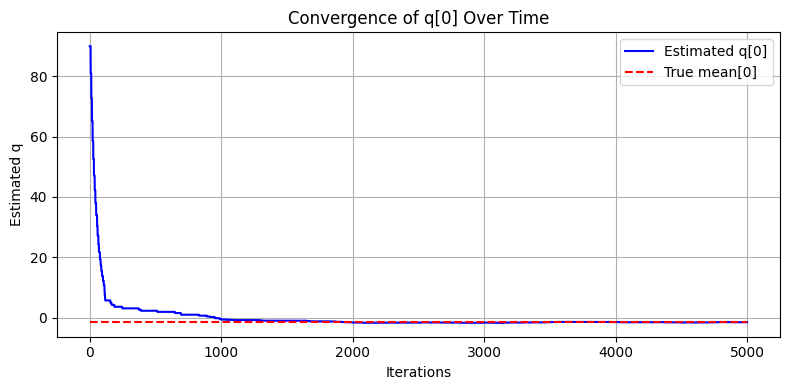

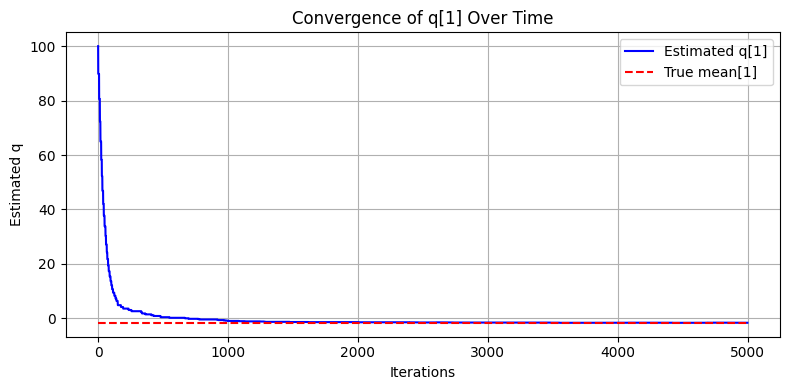

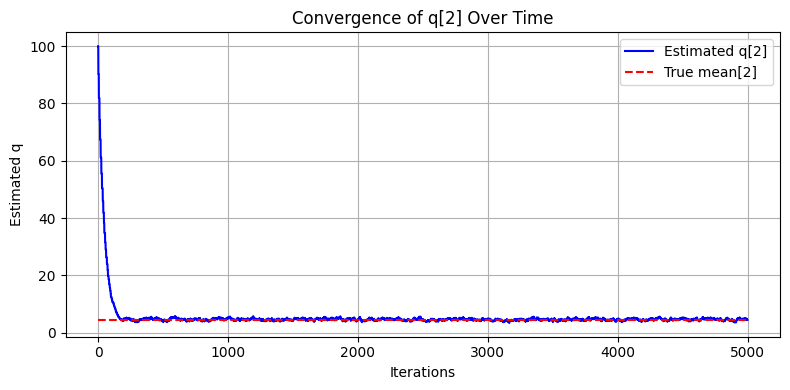

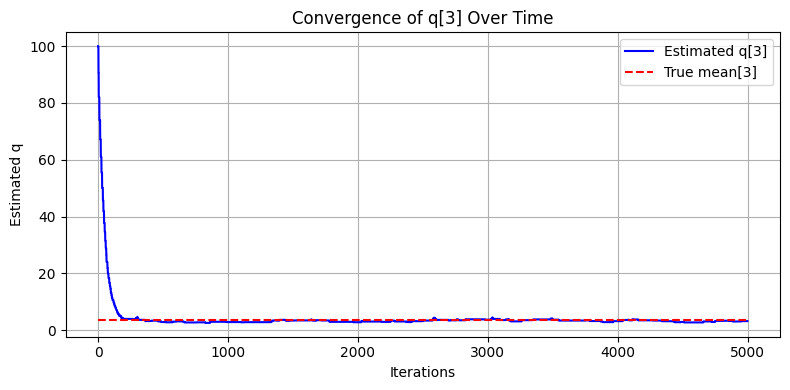

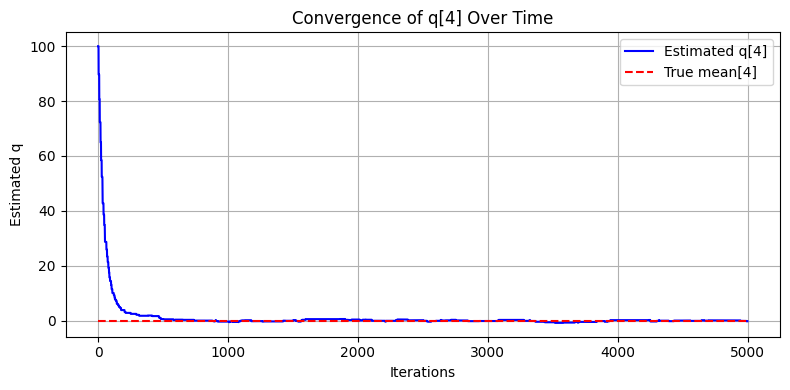

In [52]:
q_history, true_means = track_q_evolution(epsilon=0.1, alpha=0.1, attempts_no=5000)

for i, q_vals in enumerate(q_history):
    plt.figure(figsize=(8, 4))
    plt.plot(q_vals, label=f"Estimated q[{i}]", color="blue")
    plt.hlines(true_means[i], 0, len(q_vals), colors='red', linestyles='--', label=f"True mean[{i}]")
    plt.title(f"Convergence of q[{i}] Over Time")
    plt.xlabel("Iterations")
    plt.ylabel("Estimated q")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

4. Modify the environment so that the mean values of all bandits change in time. Repeat the training procedure. Evaluate its effectiveness.




In [ ]:
class NonStationaryBanditsEnvironment(BanditsEnvironment):
    def __init__(self, bandits: Iterable[Bandit], change_at=4000, penalty=1000):
        super().__init__(bandits, penalty)
        self.change_at = change_at
        self.t = 0  # time counter

    def take_action(self, a: int):
        self.t += 1
        if self.t == self.change_at:
            # we change the mean values and spans of all bandits
            for b in self.bandits:
                b.mean = 10 * (random.random() - 0.5)  # new mean value
                b.span = 5 * random.random()           # new span

        return super().take_action(a)


In [ ]:
def train_in_nonstationary_env(epsilon=0.1, alpha=0.1, bandits_no=5, attempts_no=5000, change_at=4000):
    bandits = [Bandit(10*(random.random()-0.5), 5*random.random()) for _ in range(bandits_no)]
    env = NonStationaryBanditsEnvironment(bandits, change_at=change_at)

    q = [100 for _ in range(bandits_no)]
    rewards = []
    q_history = [[] for _ in range(bandits_no)]
    means_history = [[] for _ in range(bandits_no)]

    for t in range(attempts_no):
        a = choose_eps_greedy_action(q, epsilon)
        r = env.take_action(a)
        q[a] = q[a] + alpha * (r - q[a])

        rewards.append(r)

        for i in range(bandits_no):
            q_history[i].append(q[i])
            means_history[i].append(env.bandits[i].mean)  # we track the true mean values

    return q_history, means_history, rewards, change_at


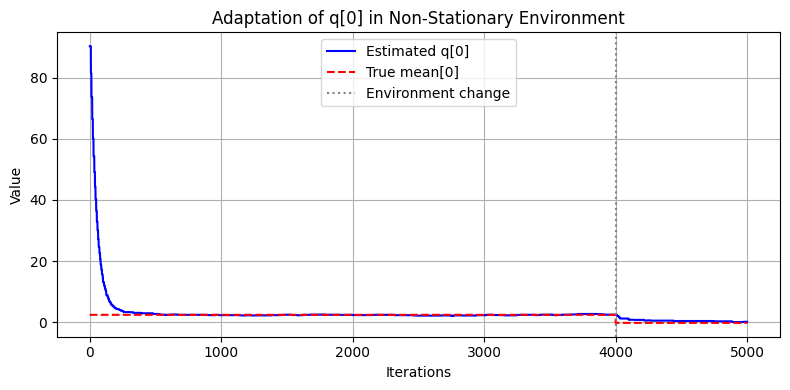

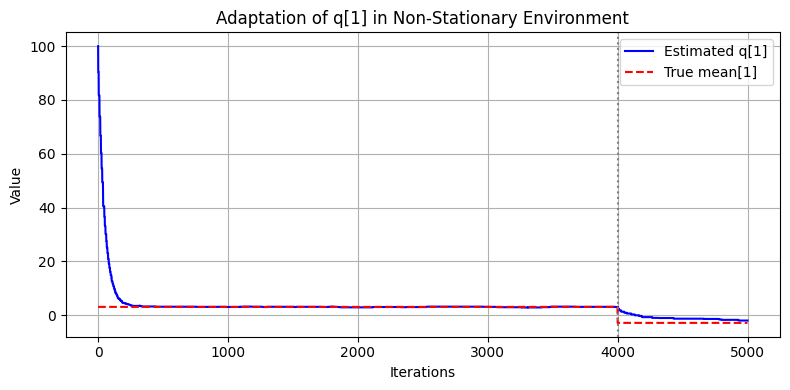

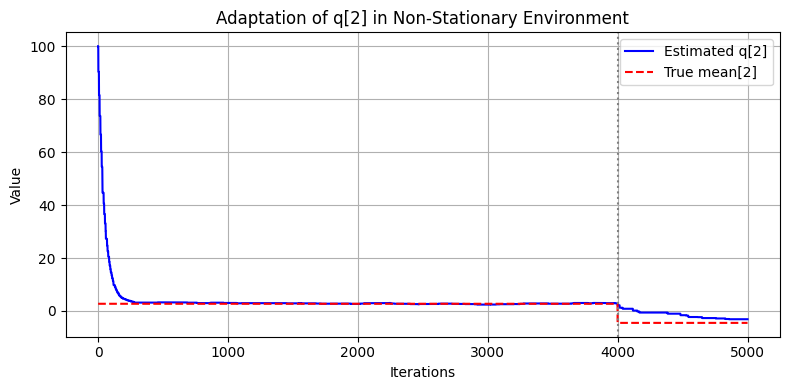

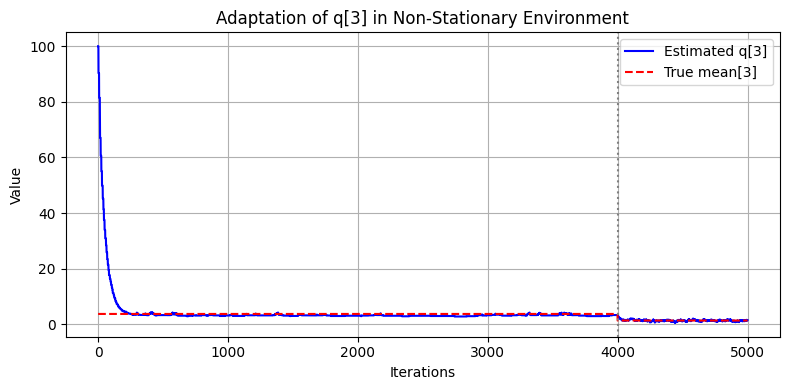

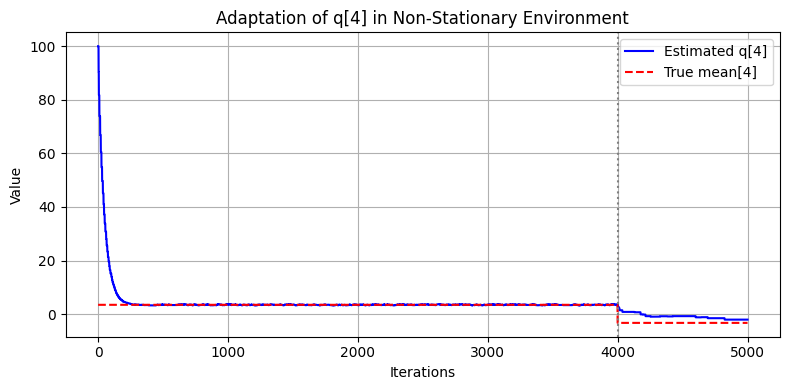

In [55]:
q_history, means_history, rewards, change_at = train_in_nonstationary_env()

for i in range(len(q_history)):
    plt.figure(figsize=(8, 4))
    plt.plot(q_history[i], label=f"Estimated q[{i}]", color="blue")
    plt.plot(means_history[i], label=f"True mean[{i}]", color="red", linestyle="--")
    plt.axvline(change_at, color='gray', linestyle=':', label="Environment change" if i == 0 else None)
    plt.title(f"Adaptation of q[{i}] in Non-Stationary Environment")
    plt.xlabel("Iterations")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [ ]:
alphas = [0.1, 0.3, 0.5]
results = []

for alpha in alphas:
    q_hist, mean_hist, _, change_at = train_in_nonstationary_env(alpha=alpha)
    results.append((alpha, q_hist[0], mean_hist[0]))  # we only track q[0] and mean[0] for simplicity

for alpha, q_vals, true_vals in results:
    plt.figure(figsize=(8, 4))
    plt.plot(q_vals, label=f"Estimated q[0] (α={alpha})", color="blue")
    plt.plot(true_vals, label=f"True mean[0]", linestyle="--", color="red")
    plt.axvline(change_at, color='gray', linestyle=':', label="Environment Change")
    plt.title(f"Effect of α = {alpha} on Adaptation Speed")
    plt.xlabel("Iterations")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()



In [ ]:
def train_with_full_q_tracking(epsilon=0.1, alpha=0.1, bandits_no=5, attempts_no=5000, change_at=4000):
    bandits = [Bandit(10*(random.random()-0.5), 5*random.random()) for _ in range(bandits_no)]
    env = NonStationaryBanditsEnvironment(bandits, change_at=change_at)

    q = [100 for _ in range(bandits_no)]
    qs = []  # list of all q vectors per iteration
    means_history = [[] for _ in range(bandits_no)]

    for t in range(attempts_no):
        a = choose_eps_greedy_action(q, epsilon)
        r = env.take_action(a)
        q[a] = q[a] + alpha * (r - q[a])

        qs.append(q.copy())  # we store the current q vector

        for i in range(bandits_no):
            means_history[i].append(env.bandits[i].mean)

    return qs, means_history, change_at


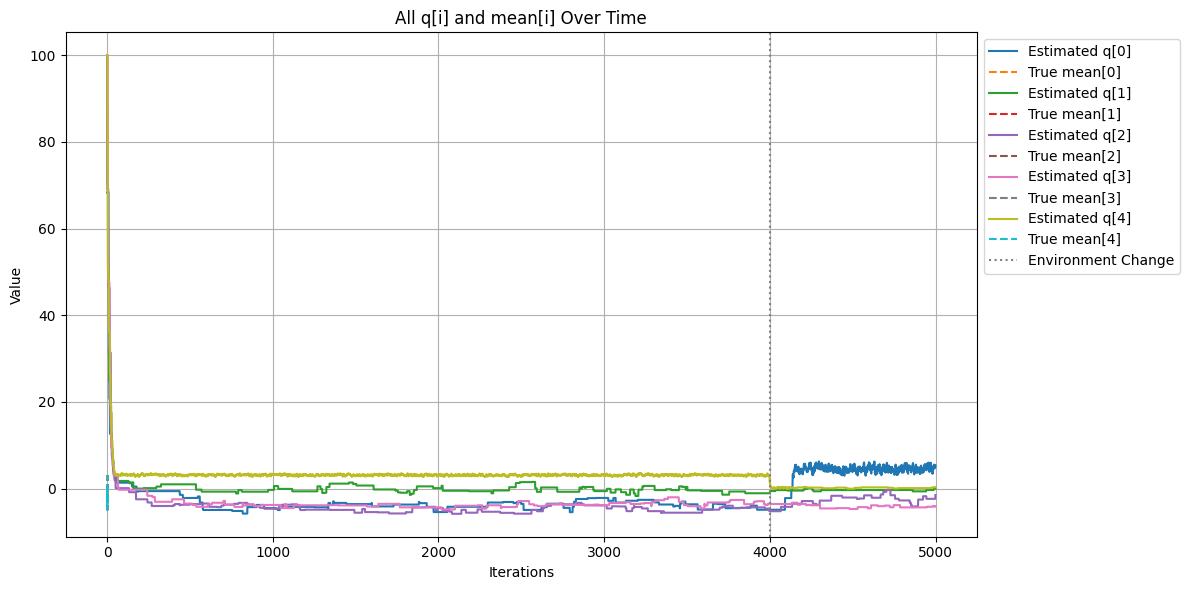

In [58]:
qs, means_history, change_at = train_with_full_q_tracking(alpha=0.3)

qs = np.array(qs)
means = np.array(means_history)

plt.figure(figsize=(12, 6))
for i in range(qs.shape[1]):
    plt.plot(qs[:, i], label=f"Estimated q[{i}]", linestyle="-")
    plt.plot(means[:, i], linestyle="--", label=f"True mean[{i}]")

plt.axvline(change_at, color='gray', linestyle=':', label="Environment Change")
plt.title("All q[i] and mean[i] Over Time")
plt.xlabel("Iterations")
plt.ylabel("Value")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.grid(True)
plt.tight_layout()
plt.show()
